In [303]:
import pandas as pd
from sklearn.linear_model import LinearRegression,Lasso,Ridge,LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error,r2_score,classification_report,confusion_matrix,mean_absolute_error,root_mean_squared_error
import numpy as np
from matplotlib import pyplot as plt
from sklearn.preprocessing import PolynomialFeatures,StandardScaler,MinMaxScaler,LabelEncoder
import seaborn as sns
from sklearn.svm import SVC
from sklearn.pipeline import Pipeline
from sklearn.naive_bayes import MultinomialNB,GaussianNB
from sklearn.tree import DecisionTreeClassifier,DecisionTreeRegressor
from imblearn.under_sampling import RandomUnderSampler
from sklearn.ensemble import RandomForestRegressor,GradientBoostingRegressor,RandomForestClassifier,GradientBoostingClassifier
from xgboost import XGBClassifier,XGBRegressor

In [304]:
df=pd.read_csv('flight_price_dataset_of_bangladesh.csv')

In [305]:
df.shape

(57000, 17)

In [306]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 57000 entries, 0 to 56999
Data columns (total 17 columns):
 #   Column                 Non-Null Count  Dtype  
---  ------                 --------------  -----  
 0   Airline                57000 non-null  object 
 1   Source                 57000 non-null  object 
 2   Source Name            57000 non-null  object 
 3   Destination            57000 non-null  object 
 4   Destination Name       57000 non-null  object 
 5   Departure Date & Time  57000 non-null  object 
 6   Arrival Date & Time    57000 non-null  object 
 7   Duration (hrs)         57000 non-null  float64
 8   Stopovers              57000 non-null  object 
 9   Aircraft Type          57000 non-null  object 
 10  Class                  57000 non-null  object 
 11  Booking Source         57000 non-null  object 
 12  Base Fare (BDT)        57000 non-null  float64
 13  Tax & Surcharge (BDT)  57000 non-null  float64
 14  Total Fare (BDT)       57000 non-null  float64
 15  Se

In [307]:
df.head(2)

,Airline,Source,Source Name,Destination,Destination Name,Departure Date & Time,Arrival Date & Time,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14


In [308]:
cols_to_drop=df[['Source Name','Destination Name','Departure Date & Time','Arrival Date & Time']]
#cols_to_drop=df[['Source Name','Destination Name','Departure Date & Time','Arrival Date & Time','Airline','Source','Destination','Stopovers','Booking Source','Days Before Departure','Seasonality']]

In [309]:
df=df.drop(cols_to_drop,axis='columns')

In [310]:
df.head(2)

,Airline,Source,Destination,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,Malaysian Airlines,CXB,CCU,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10
1,Cathay Pacific,BZL,CGP,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14


In [311]:
df['Stopovers'].value_counts()

Stopovers
Direct     36642
1 Stop     17400
2 Stops     2958
Name: count, dtype: int64

<Axes: xlabel='Stopovers'>

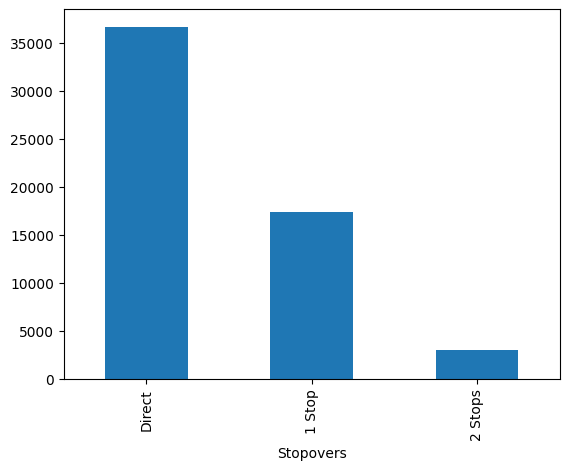

In [312]:
df['Stopovers'].value_counts().plot(kind='bar')

In [313]:
#df['Stopovers'].value_counts().plot(kind='pie',autopct='%1.1f%%')

In [314]:
df['Aircraft Type'].value_counts()

Aircraft Type
Airbus A320    23970
Boeing 787      9092
Boeing 737      8972
Airbus A350     7572
Boeing 777      7394
Name: count, dtype: int64

<Axes: xlabel='Aircraft Type'>

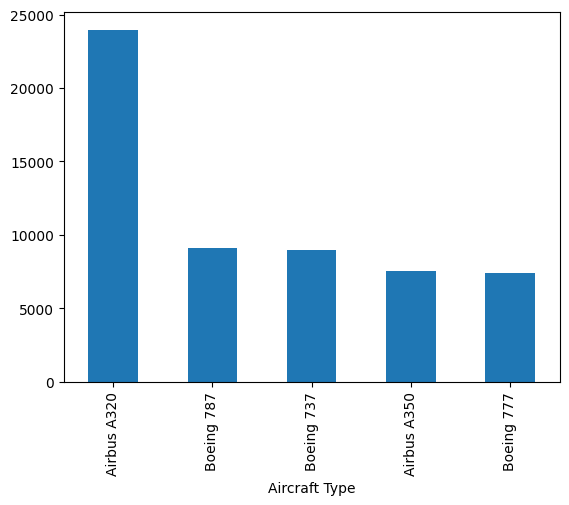

In [315]:
df['Aircraft Type'].value_counts().plot(kind='bar')

In [316]:
df['Class'].value_counts()

Class
Economy        19112
First Class    18979
Business       18909
Name: count, dtype: int64

In [317]:
df['Booking Source'].value_counts()

Booking Source
Direct Booking    19111
Online Website    18966
Travel Agency     18923
Name: count, dtype: int64

In [318]:
df['Seasonality'].value_counts()

Seasonality
Regular            44525
Winter Holidays    10930
Hajj                 942
Eid                  603
Name: count, dtype: int64

In [319]:
df['Airline'].value_counts()

Airline
US-Bangla Airlines           4496
Vistara                      2368
Lufthansa                    2368
FlyDubai                     2346
Biman Bangladesh Airlines    2344
Emirates                     2327
Saudia                       2321
Thai Airways                 2316
AirAsia                      2312
Air Astra                    2304
Malaysian Airlines           2292
Cathay Pacific               2282
Air India                    2280
Singapore Airlines           2279
NovoAir                      2268
Etihad Airways               2267
Qatar Airways                2267
Kuwait Airways               2262
Gulf Air                     2231
IndiGo                       2223
Turkish Airlines             2220
Air Arabia                   2217
British Airways              2209
SriLankan Airlines           2201
Name: count, dtype: int64

In [320]:
df['Source'].value_counts()

Source
CGP    7241
ZYL    7179
JSR    7149
DAC    7146
BZL    7102
RJH    7091
CXB    7049
SPD    7043
Name: count, dtype: int64

In [321]:
df['Destination'].value_counts()

Destination
JED    3071
DEL    3069
JFK    3066
SIN    3063
BKK    3036
DXB    3005
LHR    2968
KUL    2968
IST    2940
CCU    2938
DOH    2923
YYZ    2921
ZYL    2692
CXB    2652
SPD    2644
BZL    2641
RJH    2640
CGP    2613
DAC    2591
JSR    2559
Name: count, dtype: int64

In [322]:
df.dtypes

Airline                   object
Source                    object
Destination               object
Duration (hrs)           float64
Stopovers                 object
Aircraft Type             object
Class                     object
Booking Source            object
Base Fare (BDT)          float64
Tax & Surcharge (BDT)    float64
Total Fare (BDT)         float64
Seasonality               object
Days Before Departure      int64
dtype: object

In [323]:
cols_to_encode=df[['Airline','Source','Destination','Stopovers','Aircraft Type','Class','Booking Source','Seasonality']]
#cols_to_encode=df[['Aircraft Type','Class']]

In [324]:
label=LabelEncoder()

In [325]:
for cols in cols_to_encode:
    df[cols]=label.fit_transform(df[cols])

In [326]:
df.head(2)

,Airline,Source,Destination,Duration (hrs),Stopovers,Aircraft Type,Class,Booking Source,Base Fare (BDT),Tax & Surcharge (BDT),Total Fare (BDT),Seasonality,Days Before Departure
0,14,2,2,1.219526,2,0,1,1,21131.225021,5169.683753,26300.908775,2,10
1,6,0,3,0.608638,2,0,2,2,11605.395471,200.000000,11805.395471,2,14


In [327]:
cr=df.corr()

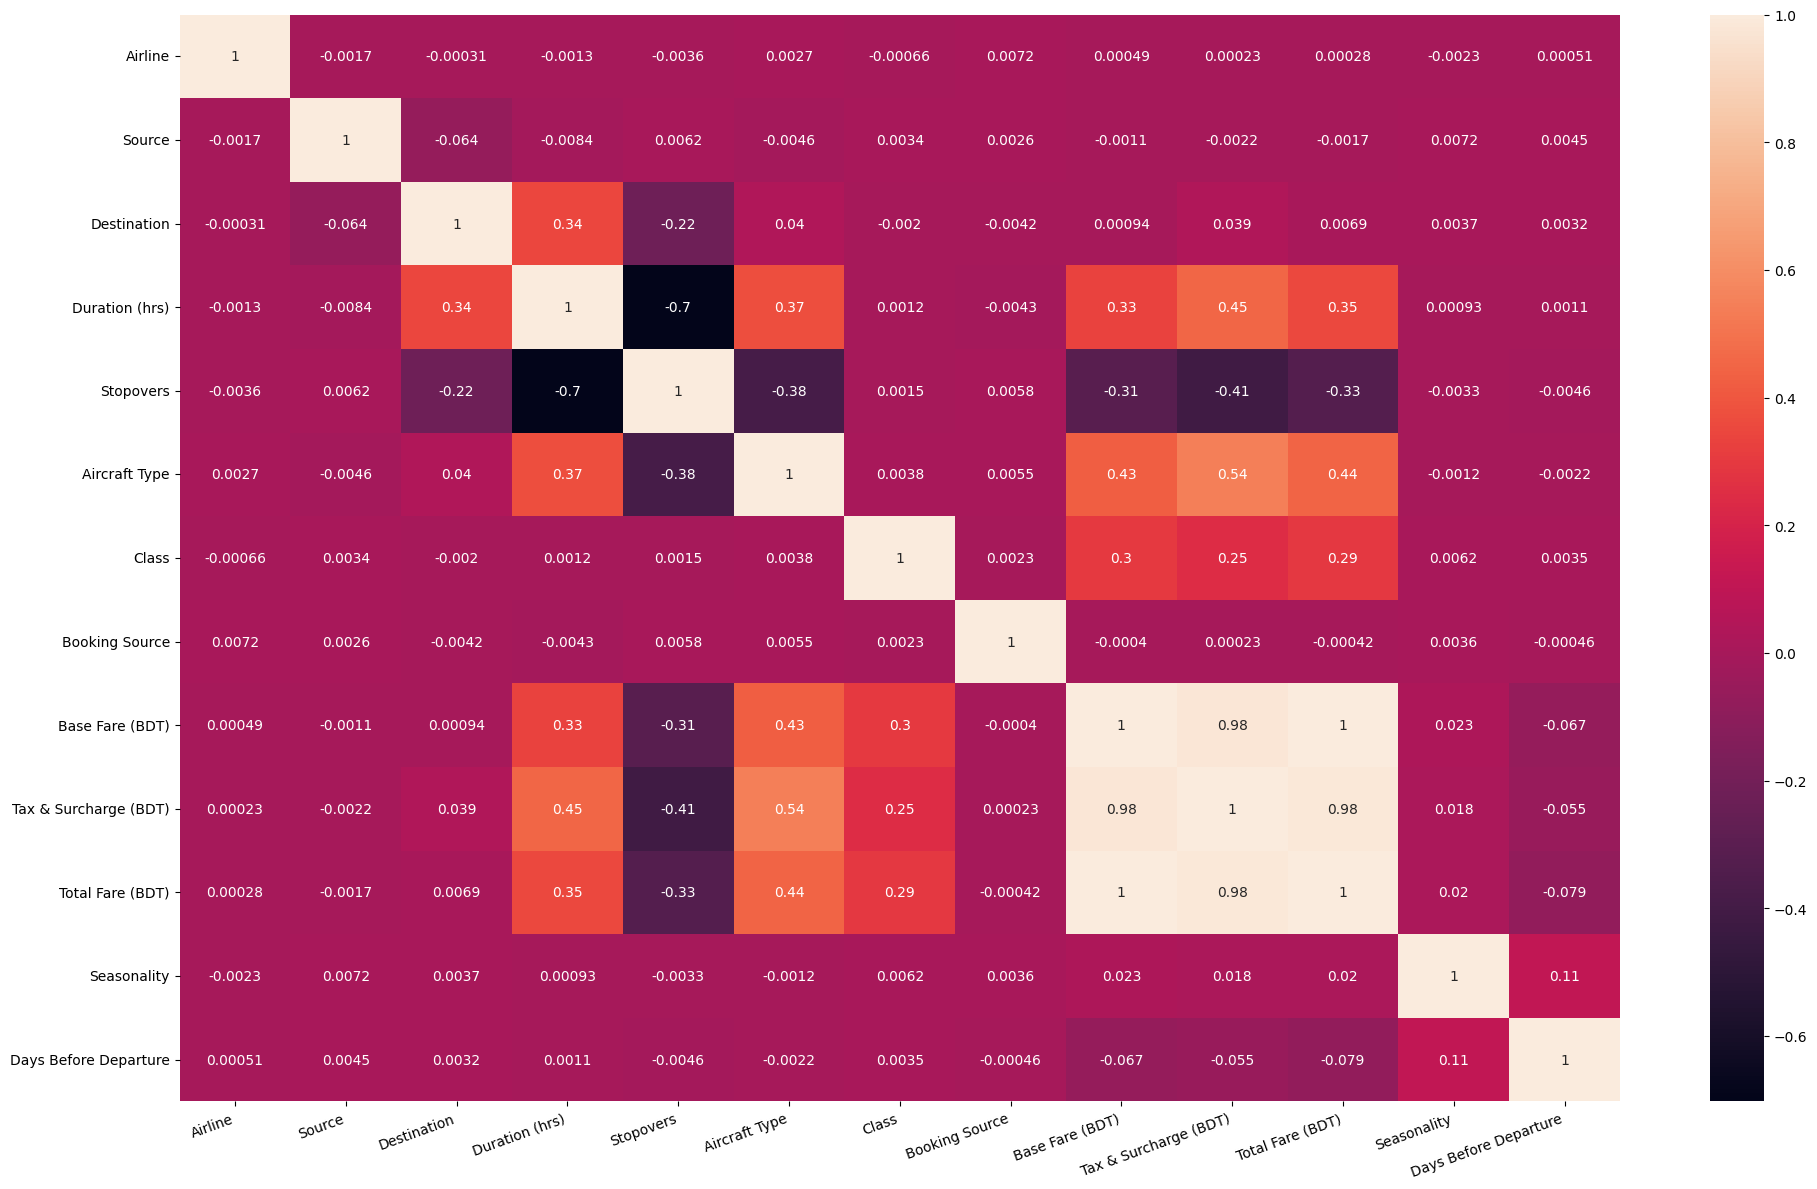

In [328]:
plt.figure(figsize=(20,12))
sns.heatmap(cr, annot=True)
plt.xticks(rotation=20, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

In [329]:
x=df.drop('Total Fare (BDT)',axis='columns')
y=df['Total Fare (BDT)']

In [330]:
x_train,x_test,y_train,y_test=train_test_split(x,y,test_size=0.2,random_state=42)

Linear Regression

In [331]:
lr=LinearRegression()

In [332]:
lr.fit(x_train,y_train)

LinearRegression()

In [333]:
lr.score(x_test,y_test)

0.9968927828269566

In [334]:
y_pred_lr=lr.predict(x_test)

In [335]:
y_pred_lr[0:10]

array([ 4905.01957448, 68837.89477306,  2167.52135207, 45459.24652508,
       55248.39317887,  9812.72721031, 74175.78018848, 92971.5537296 ,
        1867.72958844,  8549.51345454])

In [336]:
y_test[0:10]

30395     3443.680587
23048    69614.831211
46579     2598.866084
47826    46213.937843
52500    56482.820213
22882    11409.507002
56239    73870.970083
56024    93285.318817
17095     2184.296914
23585     7944.869135
Name: Total Fare (BDT), dtype: float64

In [337]:
print('r2_score:',r2_score(y_test,y_pred_lr))
print('mae:',mean_absolute_error(y_test,y_pred_lr))
print('mse:',mean_squared_error(y_test,y_pred_lr))
print('rmse:',root_mean_squared_error(y_test,y_pred_lr))

r2_score: 0.9968927828269566
mae: 1695.1011832720003
mse: 20713755.118845034
rmse: 4551.236658189182


In [338]:
model_rf=RandomForestRegressor()

In [339]:
model_rf.fit(x_train,y_train)
model_rf.score(x_test,y_test)

0.9999640389290851

In [340]:
y_pred_rf=model_rf.predict(x_test)

In [341]:
print('r2_score:',r2_score(y_test,y_pred_rf))
print('mae:',mean_absolute_error(y_test,y_pred_rf))
print('mse:',mean_squared_error(y_test,y_pred_rf))
print('rmse:',root_mean_squared_error(y_test,y_pred_rf))

r2_score: 0.9999640389290851
mae: 45.70242229467934
mse: 239728.5980534779
rmse: 489.62087175025323


In [342]:
y_test[0:10]

30395     3443.680587
23048    69614.831211
46579     2598.866084
47826    46213.937843
52500    56482.820213
22882    11409.507002
56239    73870.970083
56024    93285.318817
17095     2184.296914
23585     7944.869135
Name: Total Fare (BDT), dtype: float64

In [343]:
y_pred_rf[0:10]

array([ 3443.81784371, 69621.23711208,  2598.89480811, 46210.8519753 ,
       56484.23998809, 11404.31715115, 73880.2703753 , 93263.70642058,
        2184.56439932,  7944.6057554 ])

In [344]:
model_xg=XGBRegressor()
model_xg.fit(x_train,y_train)
model_xg.score(x_test,y_test)

0.9997094032282186

In [345]:
y_pred_xg=model_xg.predict(x_test)

In [346]:
y_test[0:10]

30395     3443.680587
23048    69614.831211
46579     2598.866084
47826    46213.937843
52500    56482.820213
22882    11409.507002
56239    73870.970083
56024    93285.318817
17095     2184.296914
23585     7944.869135
Name: Total Fare (BDT), dtype: float64

In [347]:
y_pred_xg[0:10]

array([ 3494.593 , 69333.74  ,  2637.5027, 45900.953 , 56584.08  ,
       11523.757 , 73253.44  , 92801.47  ,  2146.85  ,  7808.7427],
      dtype=float32)

In [348]:
model_dt=DecisionTreeRegressor()
model_dt.fit(x_train,y_train)
model_dt.score(x_test,y_test)

0.9999579754449925

In [349]:
y_pred_dt=model_dt.predict(x_test)

In [350]:
print('r2_score:',r2_score(y_test,y_pred_dt))
print('mae:',mean_absolute_error(y_test,y_pred_dt))
print('mse:',mean_squared_error(y_test,y_pred_dt))
print('rmse:',root_mean_squared_error(y_test,y_pred_dt))

r2_score: 0.9999579754449925
mae: 62.41375039343943
mse: 280149.8231133324
rmse: 529.2918128153244


In [351]:
y_test[0:10]

30395     3443.680587
23048    69614.831211
46579     2598.866084
47826    46213.937843
52500    56482.820213
22882    11409.507002
56239    73870.970083
56024    93285.318817
17095     2184.296914
23585     7944.869135
Name: Total Fare (BDT), dtype: float64

In [352]:
y_pred_dt[0:10]

array([ 3443.90811485, 69670.14686966,  2598.92987822, 46217.52649504,
       56491.56983351, 11391.60612697, 73892.06393167, 93275.93748676,
        2182.31242911,  7945.56472058])